# Week 4 - Exercises

## Exercise 0: The NetworkX library

In [1]:
import networkx as nx
print(nx.__version__)

3.3


In [2]:
# create a simple undirected graph
G = nx.Graph()

# add some edges (nodes are created automatically)
G.add_edge("alice", "bob", weight=3)
G.add_edge("bob", "carol", weight=1)
G.add_edge("alice", "carol", weight=2)
G.add_edge("carol", "dan", weight=5)

print(G)
print("nodes:", G.nodes())
print("edges:", G.edges())
print("alice's degree:", G.degree("alice"))


Graph with 4 nodes and 4 edges
nodes: ['alice', 'bob', 'carol', 'dan']
edges: [('alice', 'bob'), ('alice', 'carol'), ('bob', 'carol'), ('carol', 'dan')]
alice's degree: 2


## Exercise 1: Constructing the Computational Social Scientists Network

### Part 1: Network Construction

In [3]:
import json

with open("week3_css_papers.json") as f:
    papers = json.load(f)

papers[0]

{'id': 'https://openalex.org/W2047940964',
 'publication_year': 2004.0,
 'cited_by_count': 7334,
 'author_ids': ['https://openalex.org/A5014647140',
  'https://openalex.org/A5067142016',
  'https://openalex.org/A5008033989']}

In [4]:
with open("week3_css_authors.json") as f:
    authors = json.load(f)

authors[0]

{'id': 'https://openalex.org/A5014647140',
 'display_name': 'Aaron Clauset',
 'works_api_url': 'https://api.openalex.org/works?filter=author.id:A5014647140',
 'h_index': 47,
 'works_count': 267,
 'country_code': 'US'}

In [5]:
from itertools import combinations
from collections import Counter

pair_counts = Counter()

for paper in papers:
    authors_in_paper = paper["author_ids"]
    for pair in combinations(authors_in_paper, 2):
        # sort so (a, b) and (b, a) are trated as the same pair
        pair_counts[tuple(sorted(pair))] += 1

print(f"unique collaborations: {len(pair_counts)}")

unique collaborations: 73938


In [6]:
# build weighted edgelist: (author_a, author_b, weight)
weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]

# create undirected weighted graph
G = nx.Graph()
G.add_weighted_edges_from(weighted_edgelist)

print(G)

Graph with 18307 nodes and 73938 edges


In [7]:
# build a lookup dict
author_lookup = {a["id"]: a for a in authors}

# add attributes to each node
for node in G.nodes():
    if node in author_lookup:
        a = author_lookup[node]
        G.nodes[node]["display_name"] = a.get("display_name")
        G.nodes[node]["country"] = a.get("country_code")
        G.nodes[node]["h_index"] = a.get("h_index")

In [8]:
from collections import defaultdict

author_citations = defaultdict(int)
author_first_year = {}

for paper in papers:
    year = paper.get("publication_year")
    citations = paper.get("cited_by_count", 0)
    for author_id in paper["author_ids"]:
        author_citations[author_id] += citations
        if year:
            if author_id not in author_first_year:
                author_first_year[author_id] = year
            else:
                author_first_year[author_id] = min(author_first_year[author_id], year)

# add to graph
for node in G.nodes():
    G.nodes[node]["citations"] = author_citations.get(node, 0)
    G.nodes[node]["first_pub_year"] = author_first_year.get(node)

# verify on one node
sample = list(G.nodes())[0]
print(sample, G.nodes[sample])

https://openalex.org/A5014647140 {'display_name': 'Aaron Clauset', 'country': 'US', 'h_index': 47, 'citations': 19694, 'first_pub_year': 2004.0}


In [9]:
from networkx.readwrite import json_graph

G_data = json_graph.node_link_data(G)

with open("week4_css_network.json", "w") as f:
    json.dump(G_data, f)

print("saved")

saved


### Part 2: Preliminary Network Analysis

#### 1. Network Metrics

In [10]:
# nodes and edges
print(f"nodes: {G.number_of_nodes()}")
print(f"edges: {G.number_of_edges()}")

# density
density = nx.density(G)
print(f"density: {density:.6f}")

# connected?
print(f"is connected: {nx.is_connected(G)}")

# number of connected components
components = list(nx.connected_components(G))
print(f"connected components: {len(components)}")

# isolated nodes (degree 0)
isolated = list(nx.isolates(G))
print(f"isolated nodes: {len(isolated)}")

nodes: 18307
edges: 73938
density: 0.000441
is connected: False
connected components: 84
isolated nodes: 0


##### Density & connectivity discussion:

The network has a density of 0.000441, meaning only ~0.04% of all possible collaborations actually exist — this is extremely sparse, which is expected. With 18,307 authors, the maximum possible edges would be ~167 million, but we only have ~74k. In academic co-authorship networks, most researchers collaborate with a small fraction of the field, so sparsity is the norm.

The network is disconnected with 84 connected components, also unsurprising. Researchers tend to cluster around subfields, institutions, or geographic regions, forming isolated groups with no cross-connections. Notably there are 0 isolated nodes — every author has at least one collaborator, which makes sense since our data is built from papers (you need at least 2 authors to form an edge).

#### 2. Degree Analysis

In [11]:
import statistics

degrees = [d for _, d in G.degree()]
strengths = [d for _, d in G.degree(weight="weight")]

print(f"--- degree ---")
print(f"mean:   {statistics.mean(degrees):.2f}")
print(f"median: {statistics.median(degrees)}")
print(f"mode:   {statistics.mode(degrees)}")
print(f"min:    {min(degrees)}")
print(f"max:    {max(degrees)}")

print(f"\n--- strength (weighted degree) ---")
print(f"mean:   {statistics.mean(strengths):.2f}")
print(f"median: {statistics.median(strengths)}")
print(f"mode:   {statistics.mode(strengths)}")
print(f"min:    {min(strengths)}")
print(f"max:    {max(strengths)}")

--- degree ---
mean:   8.08
median: 6
mode:   5
min:    1
max:    394

--- strength (weighted degree) ---
mean:   15.58
median: 8
mode:   4
min:    1
max:    704


##### What do these metrics tell us about the network?

The degree stats show a right-skewed distribution — most authors have only a few collaborators (mode=5, median=6), but a small number of hubs pull the mean up to 8. the max degree of 394 means at least one author has collaborated with 394 unique people, which is huge.

For strength (weighted degree), the pattern is similar but more extreme — median is 8 but max is 704, meaning some authors have racked up hundreds of co-authored papers total. the gap between mean strength (15.58) and mean degree (8.08) suggests that on average, authors tend to collaborate multiple times with the same people rather than always branching out to new collaborators.

This kind of skewed distribution is a known property of real-world networks, where a few well-connected hubs dominate while most nodes have low degree.

#### 3. Top authors

In [12]:
top5 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]

for author_id, degree in top5:
    name = G.nodes[author_id].get("display_name", "unknown")
    print(f"{name}: degree={degree}")

Jiebo Luo: degree=394
Chunhua Shen: degree=261
Robert West: degree=249
Lyle Ungar: degree=239
Alex Pentland: degree=238


Most of these researchers are computer scientists / AI researchers rather than traditional social scientists. jiebo luo and chunhua shen work primarily in computer vision and image recognition — not obviously CSS. robert west and lyle ungar are more aligned: west works on web data and human behavior online, ungar on NLP and social media. alex pentland is probably the most CSS-aligned of the bunch — he's known for using mobile and sensor data to study human social behavior.

The fact that computer vision researchers like luo and shen appear at the top is a bit surprising, but it likely reflects how our dataset was built — we filtered for papers at the intersection of social science AND quantitative fields (math/physics/CS), which probably pulls in a lot of CS-heavy authors who occasionally publish on social topics. their high degree could also just reflect that they publish a lot and collaborate broadly, which inflates their position in the network regardless of how "CSS" their work actually is.

## Exercise 2: Visualize the network of Computational Social scientists

In [13]:
import netwulf as nw

# get the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(G_lcc)

Graph with 17802 nodes and 72800 edges


In [ ]:
network, config = nw.visualize(G_lcc)

In [16]:
# relabel nodes from openalex id to display_name
# (use id as fallback if no name)
label_mapping = {
    node: G_lcc.nodes[node].get("display_name") or node 
    for node in G_lcc.nodes()
}
G_lcc_labeled = nx.relabel_nodes(G_lcc, label_mapping)

network, config = nw.visualize(G_lcc_labeled)

In [18]:
# only keep nodes with degree >= 10
threshold = 20
nodes_to_keep = [n for n, d in G_lcc_labeled.degree() if d >= threshold]
G_sub = G_lcc_labeled.subgraph(nodes_to_keep).copy()

print(G_sub)

Graph with 1079 nodes and 4955 edges


In [19]:
network, config = nw.visualize(G_sub)

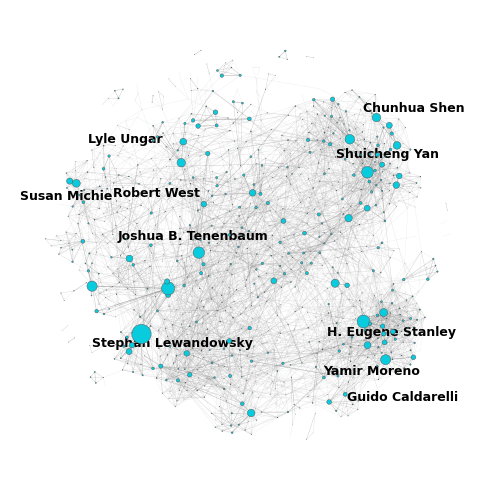

In [31]:
from netwulf import draw_netwulf
all_x = [n["x"] for n in network["nodes"]]
all_y = [n["y"] for n in network["nodes"]]
min_x, max_x = min(all_x), max(all_x)
min_y, max_y = min(all_y), max(all_y)

def scale(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin) * 812

fig, ax = draw_netwulf(network, config)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

top_nodes = sorted(G_sub.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:10]
top_names = {name for name, _ in top_nodes}

for node in network["nodes"]:
    if node["id"] in top_names:
        ax.annotate(
            node["id"],
            xy=(scale(node["x"], min_x, max_x), scale(node["y"], min_y, max_y)),
            fontsize=9,
            fontweight="bold",
            ha="center"
        )

import matplotlib.pyplot as plt
plt.savefig("week4_network.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

the network shows a clear hub-and-spoke structure — a dense core of well-connected researchers surrounded by smaller clusters on the periphery. nodes like lyle ungar, robert west, and chunhua shen are visibly larger (higher strength) and centrally positioned, suggesting they act as bridges between different research communities.

the layout also reveals some clustering — groups of nodes that are more tightly connected to each other than to the rest of the network, likely reflecting subfields or institutional collaborations. nodes on the outer edges tend to be more specialized or less prolific collaborators.